In [29]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path
import os
import glob
from PIL import Image
from IPython.display import display
from IPython.display import Image as dis_image 

In [21]:
# Load data
results_df = pd.read_table('./data_here/all_results.txt', delimiter='\t')

def read_interest_area(trial_name): #edit for L and R cases
    boundary = []
    subject = ['',[],[]]
    with open("./data_here/interest areas/"+trial_name, "r") as file:
        
        content = file.read()
        bounds = content.split('\n')
        for i in range(2):
            items = bounds[i].split()
            subject[0] = items[-1]
            
            x_coords = []
            y_coords = []
            for coord in items[2:-1]:
                x, y = map(int, coord.split(','))
                x_coords.append(x)
                y_coords.append(y)
                
            subject[1] = x_coords
            subject[2] = y_coords
            boundary.append(subject)
            subject = ['',[],[]]

    return boundary

In [22]:
def get_file_names():

    folder_path = Path("./data_here/interest areas")
    file_names = [file.name for file in folder_path.iterdir() if file.is_file()]

    return file_names

In [36]:
def plot_trial(x_plots, y_plots, trial_name, save_folder="plot_images"):
    folder_path = "./plot_images"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):  # Ensure it's a file, not a folder
            os.remove(file_path)
        
    os.makedirs(save_folder, exist_ok=True)
    
    # Filter out None values
    valid_indices = ~np.isnan(x_plots) & ~np.isnan(y_plots)
    x_plots = np.array(x_plots)[valid_indices]
    y_plots = np.array(y_plots)[valid_indices]

    boundary = read_interest_area(trial_name)
    x_bound1 = boundary[0][1]
    x_bound1.append(x_bound1[0])
    y_bound1 = boundary[0][2]
    y_bound1.append(y_bound1[0])
    x_bound2 = boundary[1][1]
    x_bound2.append(x_bound2[0])
    y_bound2 = boundary[1][2]
    y_bound2.append(y_bound2[0])

    # Generate 30 evenly spaced indices
    num_frames = 20
    indices = np.linspace(0, len(x_plots) - 1, num_frames, dtype=int)

    for i in indices:
        plt.figure(figsize=(8, 6))
        plt.plot(x_plots[:i+1], y_plots[:i+1], marker='o', linestyle='-', color='blue')
        plt.plot(x_bound1, y_bound1, marker='o', linestyle='-', color='red')
        plt.plot(x_bound2, y_bound2, marker='o', linestyle='-', color='green')
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.title('Trial')
        plot_filename = os.path.join(save_folder, f"{str(i)}.png")
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        plt.close()

def get_trial_coords(subitem):
    filtered_df = results_df[results_df['subitem'] == subitem]
    x_plots = filtered_df['X_coord'].replace('empty', None).astype(float).tolist()
    y_plots = filtered_df['Y_coord'].replace('empty', None).astype(float).tolist()
    return x_plots, y_plots

def get_trial_name(item):
    picture_name = results_df[results_df['item'] == int(item)]
    pic_name_split = picture_name['picture_name'].unique()[0][:-7].split("_")
    subject1 = pic_name_split[0]
    subject2 = pic_name_split[-1]

    file_names = get_file_names()
    for file in file_names:
        split_file = file.split("_")
        if subject1 in split_file and subject2 in split_file: # This doesn't work, items 3 7 10 17 etc does not have the same subject names
            # Might be able to use agent and patient for this with a bit of editing
            return file

    return None

def show_trial_plot(subitem):
    x_coord, y_coord = get_trial_coords(subitem)
    plot_trial(x_coord, y_coord, get_trial_name(subitem[7:]))  
    display_plot_gif()
    display(dis_image(filename="saved_gifs/animated_GMM.gif"))

In [34]:
def display_plot_gif():
    os.makedirs("saved_gifs", exist_ok=True)
    folder_path = "./saved_gifs"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):  # Ensure it's a file, not a folder
            os.remove(file_path)
            
    files = glob.glob(r"plot_images/*.png")
    files = sorted(files, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))  # Sort numerically
    
    image_array = []
    progress = 0

    for my_file in files:
        progress += 1
    
        image = Image.open(my_file)
        image_array.append(image)
        #print(progress)

    #print('image_arrays shape:', np.array(image_array).shape())
    #print(type(image_array[2]))
    # Create the figure and axes objects
    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)

    def update(i):
        im.set_array(image_array[i])
        #print(i)
        return im,

    # Create the animation object
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=200, blit=True,repeat_delay=10,)

    # Show the animation
    #plt.show()

    animation_fig.save("./saved_gifs/animated_GMM.gif")
    plt.close()

MovieWriter ffmpeg unavailable; using Pillow instead.


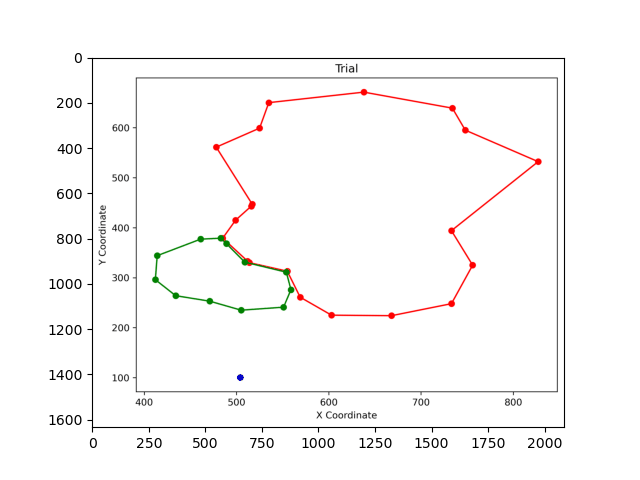

In [39]:
show_trial_plot('sub101_6')
#get_trial_name('25')

In [231]:
print(len(results_df['picture_name'].unique()))
print(results_df.columns)

['stork_carrying_baby_active' 'thief_stealing_painting_active'
 'hippie_finding_drugs_active' 'man_lifting_bench_active'
 'paparazzi_following_queen_active' 'girl_grabbing_cake_active'
 'policeman_stopping_truck_active' 'pelican_approaching_balloon_active'
 'shark_attacking_man_active' 'farmer_pulling_donkey_active'
 'jeweler_examining_diamonds_active' 'punk_kicking_fence_active'
 'frog_capturing_fly_active' 'army_beseiging_castle_active'
 'manager_congratulating_intern_active' 'cat_scratching_couch_active'
 'ambulance_knocking_over_woman_active' 'worker_moving_armchair_active'
 'lightning_striking_church_active' 'dog_running_after_postman_active'
 'artist_carving_statue_active' 'sheriff_lassoing_cowboy_active'
 'man_brushing_suit_active' 'baby_biting_bear_active'
 'burglar_smashing_window_active' 'elephant_picking_up_clown_active'
 'bodyguard_approaching_president_active' 'woman_chasing_chicken_active'
 'bomb_landing_on_ship_active' 'lifeguard_finding_child_active'
 'eskimo_attacking_

In [240]:
results_df.groupby(['patient']).count()

,item,subitem,counter,sub,IntAr,X_coord,Y_coord,Time,participant_language,input,...,the1_onset,the1_offset,agent,agent_onset,agent_offset,the2,the2_onset,the2_offset,patient_onset,patient_offset
patient,,,,,,,,,,,,,,,,,,,,,
actor,38800,38800,38800,38800,38800,38800,38800,38800,38800,38800,...,38800,38800,38800,38800,38800,38800,38800,38800,38800,38800
armchair,38000,38000,38000,38000,38000,38000,38000,38000,38000,38000,...,38000,38000,38000,38000,38000,38000,38000,38000,38000,38000
baby,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,...,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000
balloon,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,...,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000
bear,79600,79600,79600,79600,79600,79600,79600,79600,79600,79600,...,79600,79600,79600,79600,79600,79600,79600,79600,79600,79600
bench,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,...,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000
cake,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,...,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000
castle,40400,40400,40400,40400,40400,40400,40400,40400,40400,40400,...,40400,40400,40400,40400,40400,40400,40400,40400,40400,40400
cheerleader,40400,40400,40400,40400,40400,40400,40400,40400,40400,40400,...,40400,40400,40400,40400,40400,40400,40400,40400,40400,40400


In [234]:
print(list(results_df))


['item', 'subitem', 'counter', 'sub', 'IntAr', 'X_coord', 'Y_coord', 'Time', 'participant_language', 'input', 'trial_number', 'condition', 'memory_binary_response', 'RT', 'memory_accuracy', 'picture_name', 'the1', 'the1_onset', 'the1_offset', 'agent', 'agent_onset', 'agent_offset', 'the2', 'the2_onset', 'the2_offset', 'patient', 'patient_onset', 'patient_offset']
